In [1]:
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile

from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [2]:
value00 = "00000000"
value01 = "01100100"
value10 = "11001000"
value11 = "11111111"

print("00 =", value00)
print("01 =", value01)
print("10 =", value10)
print("11 =", value11)

00 = 00000000
01 = 01100100
10 = 11001000
11 = 11111111


In [3]:
idx = QuantumRegister(2, "idx")
intensity = QuantumRegister(8, "intensity")
cr = ClassicalRegister(10, "cr")

qc_image = QuantumCircuit(
    intensity,
    idx,
    cr
)

num_qubits = qc_image.num_qubits

print("Total qubits:", num_qubits)

Total qubits: 10


In [4]:
qc_image.draw()

intensity_0: 
             
intensity_1: 
             
intensity_2: 
             
intensity_3: 
             
intensity_4: 
             
intensity_5: 
             
intensity_6: 
             
intensity_7: 
             
      idx_0: 
             
      idx_1: 
             
      cr: 10/

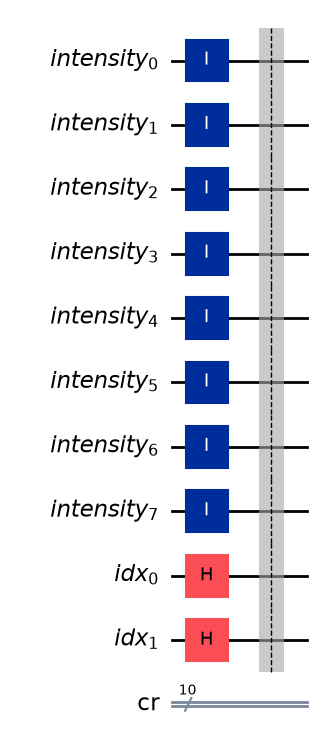

In [5]:
#Initialize the quantum circuit
for idx in range(intensity.size):
    qc_image.id(idx)
#Add Hadamard gates to the pixel positions
qc_image.h(8)
qc_image.h(9)

#Seperate with barrier so it is easy to read later
qc_image.barrier()

qc_image.draw("mpl")

In [6]:
# Encode the first pixel, since its value is 0, we will apply ID gates here:
for idx in range(num_qubits):
    qc_image.id(idx)

qc_image.barrier()
qc_image.draw()

┌───┐ ░ ┌───┐ ░ 
intensity_0: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
intensity_1: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
intensity_2: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
intensity_3: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
intensity_4: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
intensity_5: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
intensity_6: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
intensity_7: ┤ I ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
      idx_0: ┤ H ├─░─┤ I ├─░─
             ├───┤ ░ ├───┤ ░ 
      idx_1: ┤ H ├─░─┤ I ├─░─
             └───┘ ░ └───┘ ░ 
      cr: 10/════════════════

In [7]:
# Encode the second pixel whose value is (01100100):
value01 = '01100100'

# Add the NOT gate to set the position at 01:
qc_image.x(qc_image.num_qubits-1)

# We'll reverse order the value so it is in the same order when measured.
for idx, px_value in enumerate(value01[::-1]):
    if(px_value=='1'):
        qc_image.ccx(num_qubits-1, num_qubits-2, idx)

# Reset the NOT gate
qc_image.x(num_qubits-1)

qc_image.barrier()
qc_image.draw()

┌───┐ ░ ┌───┐ ░                           ░ 
intensity_0: ┤ I ├─░─┤ I ├─░───────────────────────────░─
             ├───┤ ░ ├───┤ ░                           ░ 
intensity_1: ┤ I ├─░─┤ I ├─░───────────────────────────░─
             ├───┤ ░ ├───┤ ░      ┌───┐                ░ 
intensity_2: ┤ I ├─░─┤ I ├─░──────┤ X ├────────────────░─
             ├───┤ ░ ├───┤ ░      └─┬─┘                ░ 
intensity_3: ┤ I ├─░─┤ I ├─░────────┼──────────────────░─
             ├───┤ ░ ├───┤ ░        │                  ░ 
intensity_4: ┤ I ├─░─┤ I ├─░────────┼──────────────────░─
             ├───┤ ░ ├───┤ ░        │  ┌───┐           ░ 
intensity_5: ┤ I ├─░─┤ I ├─░────────┼──┤ X ├───────────░─
             ├───┤ ░ ├───┤ ░        │  └─┬─┘┌───┐      ░ 
intensity_6: ┤ I ├─░─┤ I ├─░────────┼────┼──┤ X ├──────░─
             ├───┤ ░ ├───┤ ░        │    │  └─┬─┘      ░ 
intensity_7: ┤ I ├─░─┤ I ├─░────────┼────┼────┼────────░─
             ├───┤ ░ ├───┤ ░        │    │    │        ░ 
      idx_0: ┤ H ├─░─┤ I ├─░────────■────■────■────────░─
             ├───┤ ░ ├───┤ ░ ┌───┐  │    │    │  ┌───┐ ░ 
      idx_1: ┤ H ├─░─┤ I ├─░─┤ X ├──■────■────■──┤ X ├─░─
             └───┘ ░ └───┘ ░ └───┘               └───┘ ░ 
      cr: 10/════════════════════════════════════════════

In [8]:
# Encode the third pixel whose value is (11001000):
value10 = '11001000'

# Add the 0CNOT gates, where 0 is on X pixel:
qc_image.x(num_qubits-2)
for idx, px_value in enumerate(value10[::-1]):
    if(px_value=='1'):
        qc_image.ccx(num_qubits-1, num_qubits-2, idx)
qc_image.x(num_qubits-2)


qc_image.barrier()
qc_image.draw()

┌───┐ ░ ┌───┐ ░                           ░                     »
intensity_0: ┤ I ├─░─┤ I ├─░───────────────────────────░─────────────────────»
             ├───┤ ░ ├───┤ ░                           ░                     »
intensity_1: ┤ I ├─░─┤ I ├─░───────────────────────────░─────────────────────»
             ├───┤ ░ ├───┤ ░      ┌───┐                ░                     »
intensity_2: ┤ I ├─░─┤ I ├─░──────┤ X ├────────────────░─────────────────────»
             ├───┤ ░ ├───┤ ░      └─┬─┘                ░      ┌───┐          »
intensity_3: ┤ I ├─░─┤ I ├─░────────┼──────────────────░──────┤ X ├──────────»
             ├───┤ ░ ├───┤ ░        │                  ░      └─┬─┘          »
intensity_4: ┤ I ├─░─┤ I ├─░────────┼──────────────────░────────┼────────────»
             ├───┤ ░ ├───┤ ░        │  ┌───┐           ░        │            »
intensity_5: ┤ I ├─░─┤ I ├─░────────┼──┤ X ├───────────░────────┼────────────»
             ├───┤ ░ ├───┤ ░        │  └─┬─┘┌───┐      ░        │  ┌───┐     »
intensity_6: ┤ I ├─░─┤ I ├─░────────┼────┼──┤ X ├──────░────────┼──┤ X ├─────»
             ├───┤ ░ ├───┤ ░        │    │  └─┬─┘      ░        │  └─┬─┘┌───┐»
intensity_7: ┤ I ├─░─┤ I ├─░────────┼────┼────┼────────░────────┼────┼──┤ X ├»
             ├───┤ ░ ├───┤ ░        │    │    │        ░ ┌───┐  │    │  └─┬─┘»
      idx_0: ┤ H ├─░─┤ I ├─░────────■────■────■────────░─┤ X ├──■────■────■──»
             ├───┤ ░ ├───┤ ░ ┌───┐  │    │    │  ┌───┐ ░ └───┘  │    │    │  »
      idx_1: ┤ H ├─░─┤ I ├─░─┤ X ├──■────■────■──┤ X ├─░────────■────■────■──»
             └───┘ ░ └───┘ ░ └───┘               └───┘ ░                     »
      cr: 10/════════════════════════════════════════════════════════════════»
                                                                             »
«                   ░ 
«intensity_0: ──────░─
«                   ░ 
«intensity_1: ──────░─
«                   ░ 
«intensity_2: ──────░─
«                   ░ 
«intensity_3: ──────░─
«                   ░ 
«intensity_4: ──────░─
«                   ░ 
«intensity_5: ──────░─
«                   ░ 
«intensity_6: ──────░─
«                   ░ 
«intensity_7: ──────░─
«             ┌───┐ ░ 
«      idx_0: ┤ X ├─░─
«             └───┘ ░ 
«      idx_1: ──────░─
«                   ░ 
«      cr: 10/════════
«

In [9]:
# Encode the fourth pixel whose value is (11111111):
value11 = '11111111'

# Add the NOT gate to set the position at 11:
qc_image.x(qc_image.num_qubits-1)

# We'll reverse order the value so it is in the same order when measured.
for idx, px_value in enumerate(value11[::-1]):
    if(px_value=='1'):
        qc_image.ccx(num_qubits-1, num_qubits-2, idx)

# Reset the NOT gate
qc_image.x(num_qubits-1)

qc_image.barrier()
qc_image.draw()

┌───┐ ░ ┌───┐ ░                           ░                     »
intensity_0: ┤ I ├─░─┤ I ├─░───────────────────────────░─────────────────────»
             ├───┤ ░ ├───┤ ░                           ░                     »
intensity_1: ┤ I ├─░─┤ I ├─░───────────────────────────░─────────────────────»
             ├───┤ ░ ├───┤ ░      ┌───┐                ░                     »
intensity_2: ┤ I ├─░─┤ I ├─░──────┤ X ├────────────────░─────────────────────»
             ├───┤ ░ ├───┤ ░      └─┬─┘                ░      ┌───┐          »
intensity_3: ┤ I ├─░─┤ I ├─░────────┼──────────────────░──────┤ X ├──────────»
             ├───┤ ░ ├───┤ ░        │                  ░      └─┬─┘          »
intensity_4: ┤ I ├─░─┤ I ├─░────────┼──────────────────░────────┼────────────»
             ├───┤ ░ ├───┤ ░        │  ┌───┐           ░        │            »
intensity_5: ┤ I ├─░─┤ I ├─░────────┼──┤ X ├───────────░────────┼────────────»
             ├───┤ ░ ├───┤ ░        │  └─┬─┘┌───┐      ░        │  ┌───┐     »
intensity_6: ┤ I ├─░─┤ I ├─░────────┼────┼──┤ X ├──────░────────┼──┤ X ├─────»
             ├───┤ ░ ├───┤ ░        │    │  └─┬─┘      ░        │  └─┬─┘┌───┐»
intensity_7: ┤ I ├─░─┤ I ├─░────────┼────┼────┼────────░────────┼────┼──┤ X ├»
             ├───┤ ░ ├───┤ ░        │    │    │        ░ ┌───┐  │    │  └─┬─┘»
      idx_0: ┤ H ├─░─┤ I ├─░────────■────■────■────────░─┤ X ├──■────■────■──»
             ├───┤ ░ ├───┤ ░ ┌───┐  │    │    │  ┌───┐ ░ └───┘  │    │    │  »
      idx_1: ┤ H ├─░─┤ I ├─░─┤ X ├──■────■────■──┤ X ├─░────────■────■────■──»
             └───┘ ░ └───┘ ░ └───┘               └───┘ ░                     »
      cr: 10/════════════════════════════════════════════════════════════════»
                                                                             »
«                   ░      ┌───┐                                         ░ 
«intensity_0: ──────░──────┤ X ├─────────────────────────────────────────░─
«                   ░      └─┬─┘┌───┐                                    ░ 
«intensity_1: ──────░────────┼──┤ X ├────────────────────────────────────░─
«                   ░        │  └─┬─┘┌───┐                               ░ 
«intensity_2: ──────░────────┼────┼──┤ X ├───────────────────────────────░─
«                   ░        │    │  └─┬─┘┌───┐                          ░ 
«intensity_3: ──────░────────┼────┼────┼──┤ X ├──────────────────────────░─
«                   ░        │    │    │  └─┬─┘┌───┐                     ░ 
«intensity_4: ──────░────────┼────┼────┼────┼──┤ X ├─────────────────────░─
«                   ░        │    │    │    │  └─┬─┘┌───┐                ░ 
«intensity_5: ──────░────────┼────┼────┼────┼────┼──┤ X ├────────────────░─
«                   ░        │    │    │    │    │  └─┬─┘┌───┐           ░ 
«intensity_6: ──────░────────┼────┼────┼────┼────┼────┼──┤ X ├───────────░─
«                   ░        │    │    │    │    │    │  └─┬─┘┌───┐      ░ 
«intensity_7: ──────░────────┼────┼────┼────┼────┼────┼────┼──┤ X ├──────░─
«             ┌───┐ ░        │    │    │    │    │    │    │  └─┬─┘      ░ 
«      idx_0: ┤ X ├─░────────■────■────■────■────■────■────■────■────────░─
«             └───┘ ░ ┌───┐  │    │    │    │    │    │    │    │  ┌───┐ ░ 
«      idx_1: ──────░─┤ X ├──■────■────■────■────■────■────■────■──┤ X ├─░─
«                   ░ └───┘                                        └───┘ ░ 
«      cr: 10/═════════════════════════════════════════════════════════════
«

In [10]:
print('Circuit dimensions')
print('Circuit depth: ', qc_image.decompose().depth())
print('Circuit size: ', qc_image.decompose().size())

qc_image.decompose().count_ops()

Circuit dimensions
Circuit depth:  148
Circuit size:  236


OrderedDict([('cx', 84),
             ('t', 56),
             ('tdg', 42),
             ('h', 28),
             ('id', 18),
             ('u', 8),
             ('barrier', 5)])

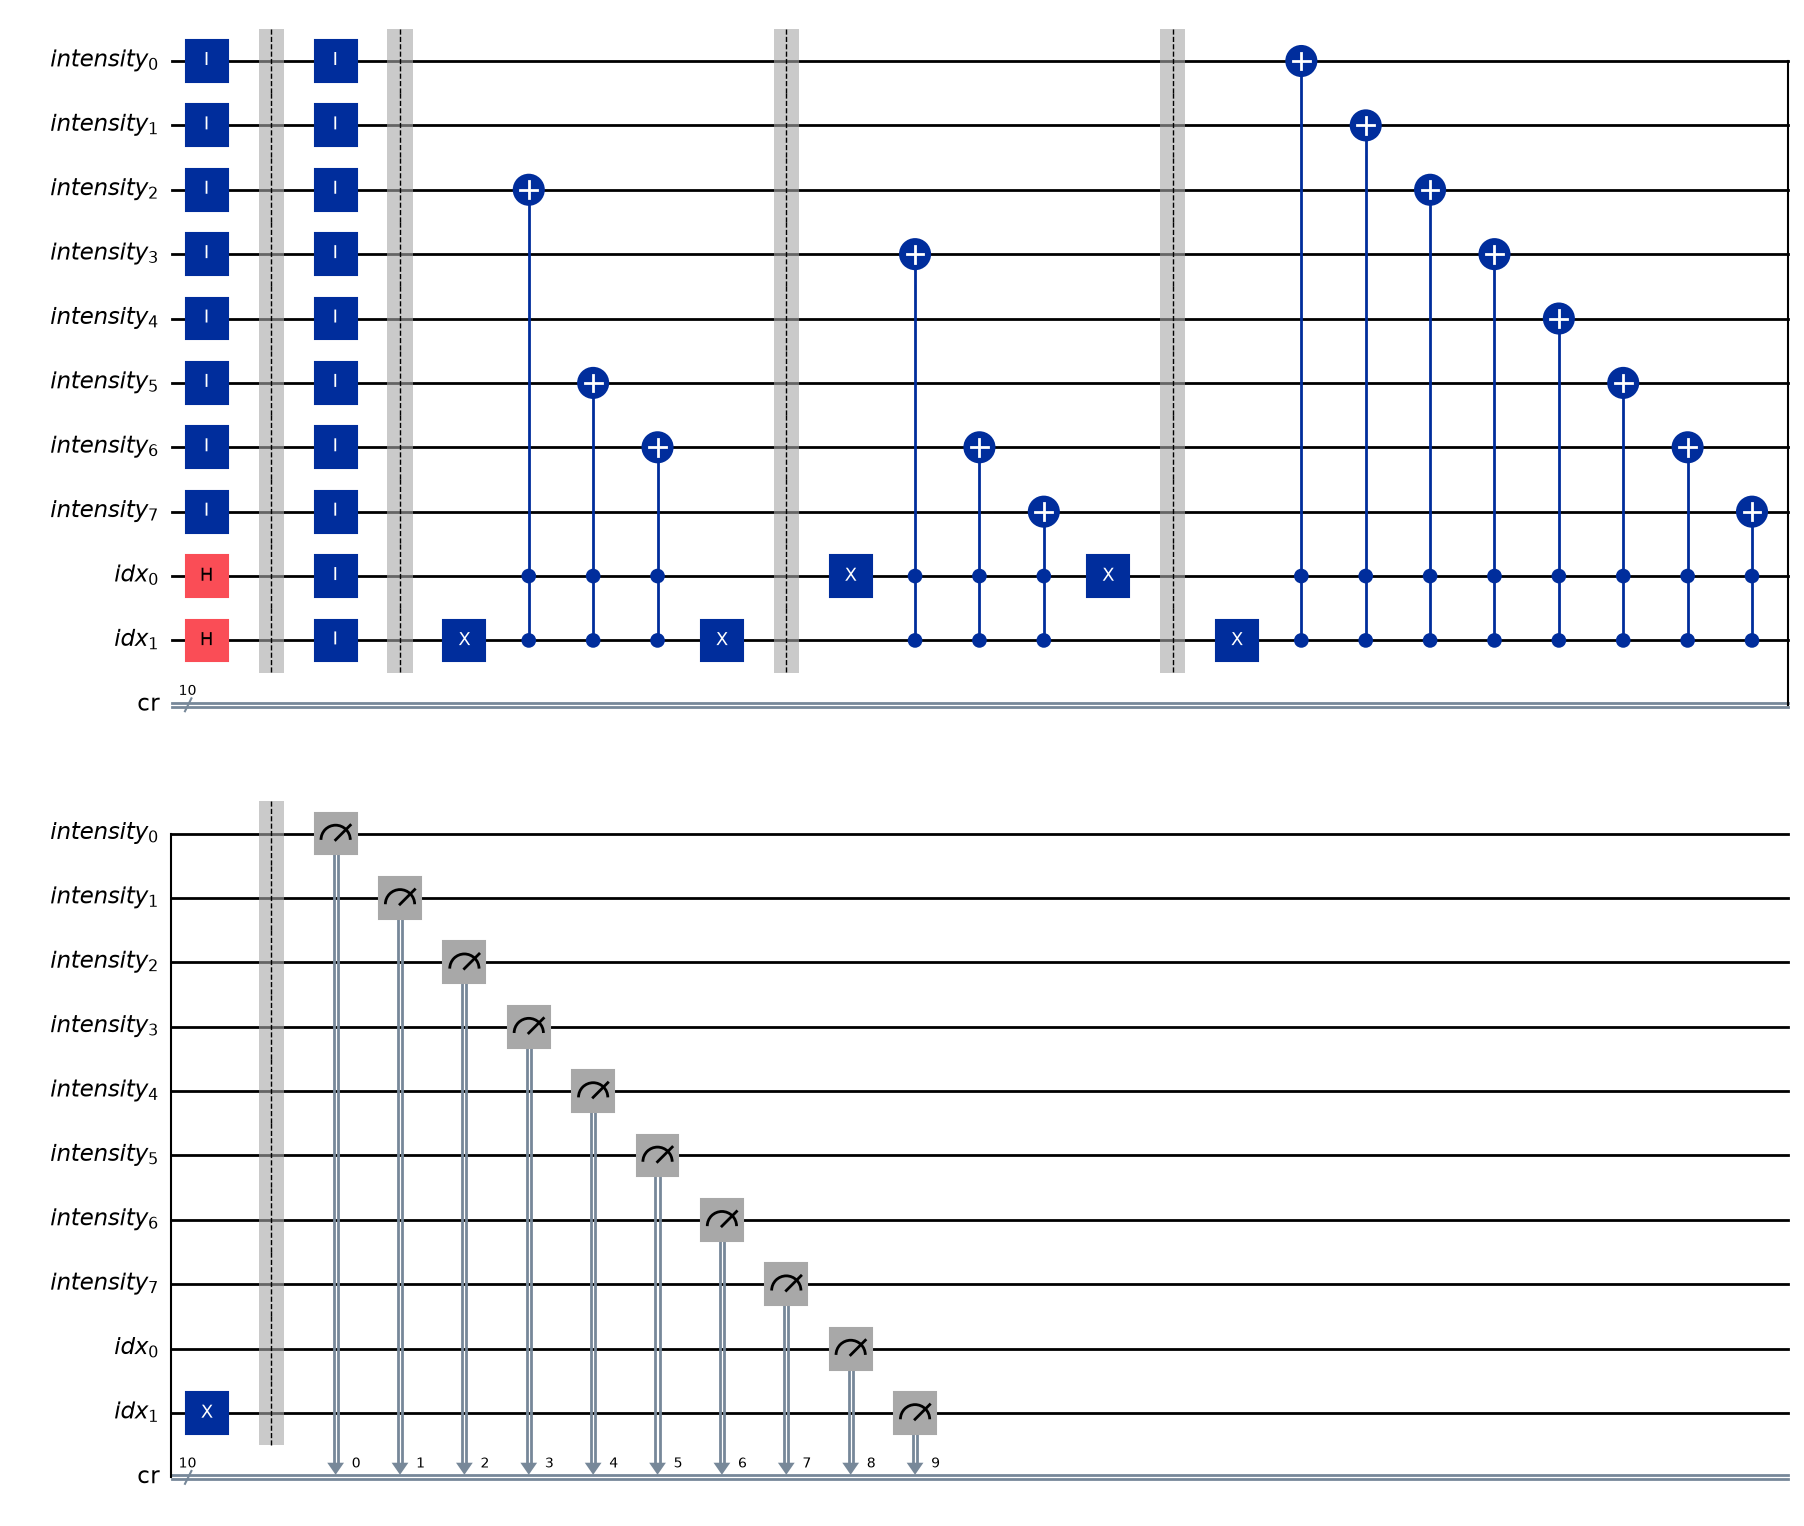

In [11]:
# Measure all 10 qubits into the 10 classical bits
qc_image.measure(
    range(10),
    range(10)
)

qc_image.draw("mpl")

In [12]:
print(qc_image.count_ops())

OrderedDict({'id': 18, 'ccx': 14, 'measure': 10, 'x': 6, 'barrier': 5, 'h': 2})


Encoded: 00 = 00000000
Encoded: 01 = 01100100
Encoded: 10 = 11001000
Encoded: 11 = 11111111

Measurement counts:
{'0000000000': 2031, '0110011011': 2092, '1011001000': 2060, '1100000000': 2009}


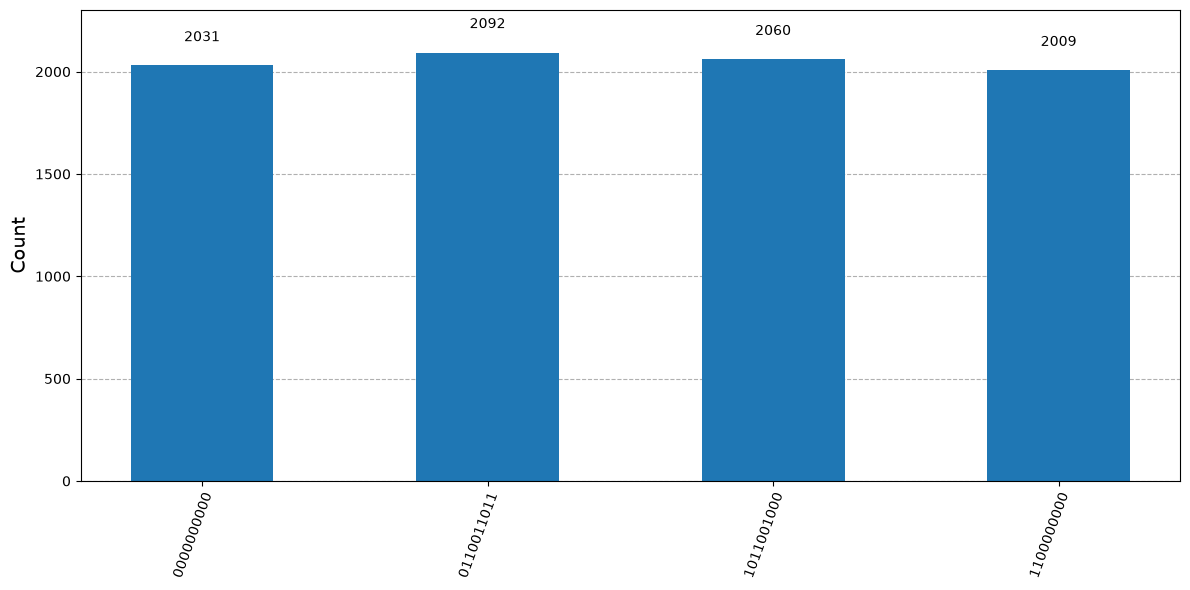

In [13]:
aer_sim = AerSimulator()

# Transpile the measured circuit
t_qc_image = transpile(
    qc_image,
    aer_sim
)

# Run the circuit
job_neqr = aer_sim.run(
    t_qc_image,
    shots=8192
)

# Get result
result_neqr = job_neqr.result()

# Get measurement counts
counts_neqr = result_neqr.get_counts()

print("Encoded: 00 = 00000000")
print("Encoded: 01 = 01100100")
print("Encoded: 10 = 11001000")
print("Encoded: 11 = 11111111")

print("\nMeasurement counts:")
print(counts_neqr)

plot_histogram(
    counts_neqr,
    figsize=(12, 6)
)

In [14]:
print("Qubits:", qc_image.num_qubits)
print("Classical bits:", qc_image.num_clbits)
print("Measurements:", qc_image.count_ops().get("measure", 0))

Qubits: 10
Classical bits: 10
Measurements: 10
